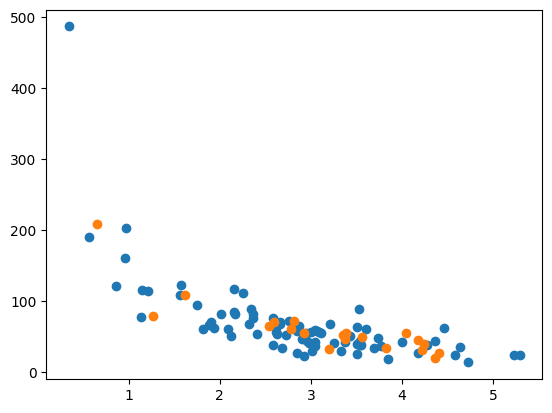

In [ ]:
import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

plt.scatter(train_x, train_y)
plt.scatter(test_x, test_y)
plt.show()

In [ ]:
import numpy
from sklearn.metrics import r2_score
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:70]
train_y = y[:70]

test_x = x[70:]
test_y = y[70:]

mymodel = numpy.poly1d(numpy.polyfit(train_x, train_y, 4))

r2 = r2_score(train_y, mymodel(train_x))

print(r2)

0.7128357965922308


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Create synthetic dataset
data = pd.DataFrame({
    'feature1': np.random.rand(100),
    'feature2': np.random.rand(100),
    'target': np.random.randint(0, 2, 100)
})

X = data[['feature1', 'feature2']]
y = data['target']

# === TRAIN-TEST SPLIT ===
print("=== Splitting Data ===")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42   # Reproducibility
)

print(f"Total samples: {len(data)}")
print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")

# === TRAIN-VALIDATION-TEST SPLIT ===
print("\n=== Train-Validation-Test Split ===")
# First split: Train (80%) + Others (20%)
X_train_full, X_temp, y_train_full, y_temp = train_test_split(X, y, test_size=0.2)
# Second split: Validation (10%) + Test (10%)
X_val, X_test_final, y_val, y_test_final = train_test_split(X_temp, y_temp, test_size=0.5)

print(f"Train: {len(X_train_full)}, Val: {len(X_val)}, Test: {len(X_test_final)}")

=== Splitting Data ===
Total samples: 100
Training set: 80 samples
Testing set: 20 samples

=== Train-Validation-Test Split ===
Train: 80, Val: 10, Test: 10


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

np.random.seed(42)

print("="*70)
print("TRAIN-TEST SPLIT: TOMATO DISEASE CLASSIFICATION")
print("="*70)

# Simulate tomato plant disease data
n_plants = 300

data = pd.DataFrame({
    'Leaf_color_score': np.random.uniform(0, 10, n_plants),
    'Spot_density': np.random.uniform(0, 100, n_plants),
    'Leaf_curl_index': np.random.uniform(0, 5, n_plants),
    'Stem_discoloration': np.random.uniform(0, 10, n_plants),
    'Growth_rate': np.random.uniform(0, 10, n_plants)
})

# Disease classification (0=Healthy, 1=Bacterial, 2=Fungal, 3=Viral)
disease = np.random.choice([0, 1, 2, 3], n_plants, p=[0.5, 0.2, 0.2, 0.1])

print(f"Dataset: {len(data)} tomato plants")
print(f"Features: {list(data.columns)}")
print(f"\nDisease distribution:")
print(f"  Healthy: {sum(disease==0)}")
print(f"  Bacterial: {sum(disease==1)}")
print(f"  Fungal: {sum(disease==2)}")
print(f"  Viral: {sum(disease==3)}")

X = data
y = disease

# Method 1: Simple split
print("\n" + "="*70)
print("METHOD 1: Simple 80-20 Split")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} plants")
print(f"Test set: {len(X_test)} plants")

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"\nTraining accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Difference: {train_acc - test_acc:.3f}")

if train_acc - test_acc > 0.1:
    print("WARNING: Large gap suggests overfitting!")
else:
    print("Good: Model generalizes well")

# Method 2: Stratified split
print("\n" + "="*70)
print("METHOD 2: Stratified 80-20 Split")
print("="*70)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nClass distribution comparison:")
print(f"{'Class':<12} {'Original':<12} {'Train':<12} {'Test':<12}")
print("-" * 50)
for cls in range(4):
    orig_pct = sum(y==cls)/len(y)*100
    train_pct = sum(y_train_s==cls)/len(y_train_s)*100
    test_pct = sum(y_test_s==cls)/len(y_test_s)*100
    print(f"{cls:<12} {orig_pct:>6.1f}%{' '*5} {train_pct:>6.1f}%{' '*5} {test_pct:>6.1f}%")

model_s = RandomForestClassifier(n_estimators=100, random_state=42)
model_s.fit(X_train_s, y_train_s)

print(f"\nStratified Test Accuracy: {model_s.score(X_test_s, y_test_s):.3f}")

# Confusion Matrix
y_pred = model_s.predict(X_test_s)
cm = confusion_matrix(y_test_s, y_pred)

print("\nConfusion Matrix:")
print("Predicted ->  H   B   F   V")
print(f"Actual H     {cm[0,0]:3d} {cm[0,1]:3d} {cm[0,2]:3d} {cm[0,3]:3d}")
print(f"       B     {cm[1,0]:3d} {cm[1,1]:3d} {cm[1,2]:3d} {cm[1,3]:3d}")
print(f"       F     {cm[2,0]:3d} {cm[2,1]:3d} {cm[2,2]:3d} {cm[2,3]:3d}")
print(f"       V     {cm[3,0]:3d} {cm[3,1]:3d} {cm[3,2]:3d} {cm[3,3]:3d}")

print("\nKEY TAKEAWAYS:")
print("1. Always split BEFORE training")
print("2. Never use test data for training")
print("3. Use stratified split for imbalanced data")
print("4. Random state ensures reproducibility")

TRAIN-TEST SPLIT: TOMATO DISEASE CLASSIFICATION
Dataset: 300 tomato plants
Features: ['Leaf_color_score', 'Spot_density', 'Leaf_curl_index', 'Stem_discoloration', 'Growth_rate']

Disease distribution:
  Healthy: 152
  Bacterial: 66
  Fungal: 54
  Viral: 28

METHOD 1: Simple 80-20 Split

Training set: 240 plants
Test set: 60 plants

Training accuracy: 1.000
Test accuracy: 0.567
Difference: 0.433

METHOD 2: Stratified 80-20 Split

Class distribution comparison:
Class        Original     Train        Test        
--------------------------------------------------
0              50.7%        50.8%        50.0%
1              22.0%        22.1%        21.7%
2              18.0%        17.9%        18.3%
3               9.3%         9.2%        10.0%

Stratified Test Accuracy: 0.433

Confusion Matrix:
Predicted ->  H   B   F   V
Actual H      24   2   4   0
       B      11   2   0   0
       F       8   3   0   0
       V       5   0   1   0

KEY TAKEAWAYS:
1. Always split BEFORE training
2

Degree 1 (Underfit): Too simple, misses the curve.
Degree 4 (Good): Captures the cosine wave.
Degree 15 (Overfit): Wiggles to hit every single noise point.


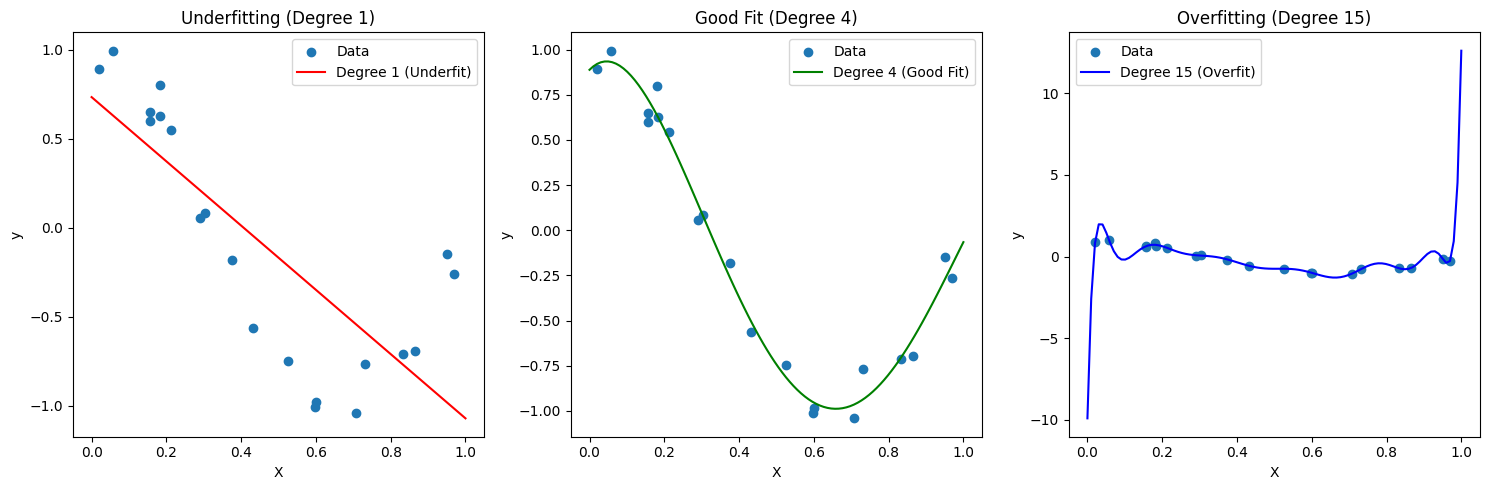

In [ ]:
import numpy
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate noisy non-linear data
numpy.random.seed(42)
X = numpy.sort(numpy.random.rand(20))
y = numpy.cos(1.5 * numpy.pi * X) + numpy.random.normal(0, 0.1, 20)
X = X[:, numpy.newaxis]

# Model 1: Underfit (Degree 1 - Line) -> High Bias
model1 = LinearRegression().fit(X, y)

# Model 2: Good Fit (Degree 4) -> Balanced
model4 = make_pipeline(PolynomialFeatures(4), LinearRegression()).fit(X, y)

# Model 3: Overfit (Degree 15) -> High Variance
model15 = make_pipeline(PolynomialFeatures(15), LinearRegression()).fit(X, y)

print("Degree 1 (Underfit): Too simple, misses the curve.")
print("Degree 4 (Good): Captures the cosine wave.")
print("Degree 15 (Overfit): Wiggles to hit every single noise point.")

# Plotting the models
x_plot = numpy.linspace(0, 1, 100).reshape(-1, 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X, y, label='Data')
plt.plot(x_plot, model1.predict(x_plot), color='red', label='Degree 1 (Underfit)')
plt.title('Underfitting (Degree 1)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, label='Data')
plt.plot(x_plot, model4.predict(x_plot), color='green', label='Degree 4 (Good Fit)')
plt.title('Good Fit (Degree 4)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, label='Data')
plt.plot(x_plot, model15.predict(x_plot), color='blue', label='Degree 15 (Overfit)')
plt.title('Overfitting (Degree 15)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Crop disease classification
np.random.seed(42)
n = 150

# Generate features
leaf_color = np.random.choice(['Green', 'Yellow', 'Brown'], n)
spot_density = np.random.uniform(0, 100, n)
leaf_curl = np.random.choice(['None', 'Mild', 'Severe'], n)
humidity = np.random.uniform(40, 95, n)

# Disease based on symptoms
disease = []
for i in range(n):
    if leaf_color[i] == 'Brown' and spot_density[i] > 60:
        disease.append('Blight')
    elif leaf_curl[i] == 'Severe' or (humidity[i] > 80 and spot_density[i] > 40):
        disease.append('Virus')
    else:
        disease.append('Healthy')

# Convert to numeric for sklearn
color_map = {'Green': 0, 'Yellow': 1, 'Brown': 2}
curl_map = {'None': 0, 'Mild': 1, 'Severe': 2}

X = pd.DataFrame({
    'Leaf_Color': [color_map[c] for c in leaf_color],
    'Spot_Density': spot_density,
    'Leaf_Curl': [curl_map[c] for c in leaf_curl],
    'Humidity': humidity
})
y = pd.Series(disease)

print('Decision Tree for Crop Disease Classification')
print('='*60)
print(f'Problem: Classify plant disease based on symptoms')
print(f'Classes: {y.unique()}')
print(f'Class distribution:')
print(y.value_counts())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Train decision tree
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    criterion='gini',
    random_state=42
)
tree.fit(X_train, y_train)

print(f'\nDecision Tree Parameters:')
print(f'  Max depth: {tree.max_depth}')
print(f'  Min samples to split: {tree.min_samples_split}')
print(f'  Criterion: {tree.criterion}')
print(f'  Tree depth achieved: {tree.get_depth()}')
print(f'  Number of leaves: {tree.get_n_leaves()}')

# Predictions
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'\nModel Performance:')
print(f'Training accuracy: {tree.score(X_train, y_train):.3f}')
print(f'Test accuracy: {accuracy:.3f}')

print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nFeature Importances:')
print(importance_df)

# Sample decision path
sample_idx = 0
sample = X_test.iloc[sample_idx:sample_idx+1]
actual = y_test.iloc[sample_idx]
predicted = y_pred[sample_idx]

print(f'\nSample Prediction:')
print(f'Features: {dict(sample.iloc[0])}')
print(f'Actual: {actual}')
print(f'Predicted: {predicted}')

# Tree visualization info
print(f'\nDecision Tree Structure:')
print(f'  Total nodes: {tree.tree_.node_count}')
print(f'  Decision nodes: {tree.tree_.node_count - tree.get_n_leaves()}')
print(f'  Leaf nodes: {tree.get_n_leaves()}')
print('\n(Tree can be visualized using plot_tree function)')

Decision Tree for Crop Disease Classification
Problem: Classify plant disease based on symptoms
Classes: ['Virus' 'Healthy' 'Blight']
Class distribution:
Healthy    72
Virus      53
Blight     25
Name: count, dtype: int64

Decision Tree Parameters:
  Max depth: 4
  Min samples to split: 10
  Criterion: gini
  Tree depth achieved: 4
  Number of leaves: 8

Model Performance:
Training accuracy: 0.964
Test accuracy: 0.974

Classification Report:
              precision    recall  f1-score   support

      Blight       1.00      1.00      1.00         6
     Healthy       1.00      0.94      0.97        18
       Virus       0.93      1.00      0.97        14

    accuracy                           0.97        38
   macro avg       0.98      0.98      0.98        38
weighted avg       0.98      0.97      0.97        38


Feature Importances:
        Feature  Importance
2     Leaf_Curl    0.388095
0    Leaf_Color    0.231797
1  Spot_Density    0.215896
3      Humidity    0.164213

Sample Pre